In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from config import config
import os
import torch

os.chdir(config.paths.roots.project)

# Check Data Module

In [3]:
from src import MatchesDataModule
dm = MatchesDataModule()

dm.prepare_data()
dm.setup(stage='fit')

INFO     | setup | Train Dataset       : 790 samples
INFO     | setup | Validation Dataset  : 198 samples


In [4]:
dl = dm.train_dataloader()

In [5]:
batch = next(iter(dl))

In [7]:
reference_patches = batch.reference_patches
target_patches = batch.target_patches
print(reference_patches.shape, target_patches.shape) 

patch_level_reference_coords = batch.patch_level_reference_coords
patch_level_target_coords = batch.patch_level_target_coords
print(patch_level_reference_coords.shape, patch_level_target_coords.shape)

torch.Size([80, 3, 32, 32]) torch.Size([80, 3, 32, 32])
torch.Size([80, 2]) torch.Size([80, 2])


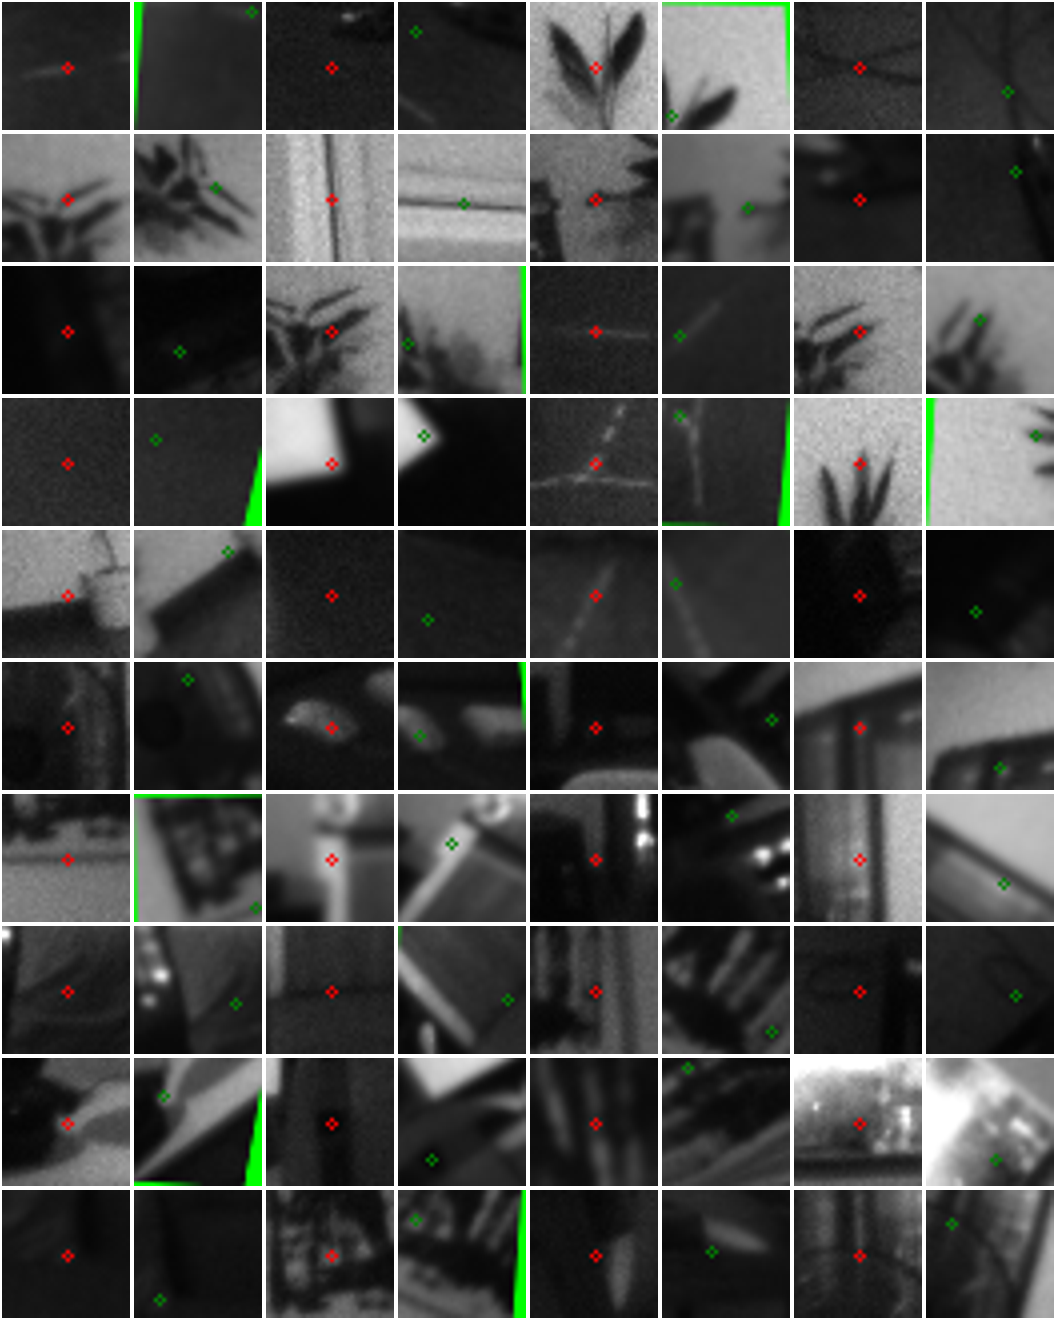

In [8]:
from utils import show_batch

show_batch(
    reference_patches, target_patches,
    patch_level_reference_coords, patch_level_target_coords,
    limit_count=40, 
    n_columns=4,
)

In [9]:
dm.teardown()

# Check Model

In [10]:
from src import DescriptorModel
model = DescriptorModel()

INFO     | __init__ | Number of Trainable Parameters : 388614


In [11]:
out = model.forward_shapes(reference_patches)

DEBUG    | forward_shapes | Input Shape : torch.Size([80, 3, 32, 32])
DEBUG    | forward_shapes | Processing ResidualBlock 1
DEBUG    | shape_hook | After Conv2d : torch.Size([80, 64, 32, 32])
DEBUG    | shape_hook | After Conv2d : torch.Size([80, 64, 32, 32])
DEBUG    | shape_hook | After Conv2d : torch.Size([80, 64, 32, 32])
DEBUG    | hook | After ResidualBlock 1 : torch.Size([80, 64, 32, 32])
DEBUG    | forward_shapes | Processing ResidualBlock 2
DEBUG    | shape_hook | After Conv2d : torch.Size([80, 128, 32, 32])
DEBUG    | shape_hook | After Conv2d : torch.Size([80, 128, 32, 32])
DEBUG    | shape_hook | After Conv2d : torch.Size([80, 128, 32, 32])
DEBUG    | hook | After ResidualBlock 2 : torch.Size([80, 128, 32, 32])
DEBUG    | forward_shapes | Processing ResidualBlock 3
DEBUG    | shape_hook | After Conv2d : torch.Size([80, 64, 32, 32])
DEBUG    | shape_hook | After Conv2d : torch.Size([80, 64, 32, 32])
DEBUG    | shape_hook | After Conv2d : torch.Size([80, 64, 32, 32])
DEBUG  

In [ ]:
# print(f'Input shape : {reference_patches.shape}')
# out = model(reference_patches)
# print(f'Output shape : {out.shape}')

# Check Light

In [12]:
from src import Light
light = Light()

INFO     | __init__ | Number of Trainable Parameters : 388614


In [13]:
target_patch_level_coords_pred = light.forward(
    reference_patches, 
    target_patches, 
    patch_level_reference_coords
)

print(target_patch_level_coords_pred.shape)

torch.Size([80, 2])
